In [3]:
import pandas as pd 
import numpy as np 
from sqlalchemy import  create_engine
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
engine = create_engine(
    "mssql+pyodbc://RAHUL\\SQLEXPRESS/alabs"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

In [53]:
cust_df = pd.read_sql("select * from customer_account_360",con=engine)

In [54]:
cust_df.shape

(5369, 35)

In [55]:
cust_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5369 entries, 0 to 5368
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   client_id                  5369 non-null   int64         
 1   birth                      5369 non-null   datetime64[ns]
 2   gender                     5369 non-null   object        
 3   age                        5369 non-null   int64         
 4   district_id                5369 non-null   int64         
 5   client_district            5369 non-null   object        
 6   client_region              5369 non-null   object        
 7   total_account              5369 non-null   int64         
 8   is_account_owner           5369 non-null   int64         
 9   is_account_user            5369 non-null   int64         
 10  account_id                 5369 non-null   int64         
 11  account_type               5369 non-null   object        
 12  date  

In [56]:
cust_df.head()

,client_id,birth,gender,age,district_id,client_district,client_region,total_account,is_account_owner,is_account_user,...,first_loan_date,avg_loan_amount,problematic_loan_count,total_orders,total_order_amount,avg_order_amount,total_classic_card,total_gold_card,total_junior_card,total_card
0,1,1970-12-13,Female,51,18,Pisek,south Bohemia,1,1,0,...,None,0,0,1,2452.000000,2452.000000,0,0,0,0
1,2,1945-02-04,Male,76,1,Hl.m. Praha,Prague,1,1,0,...,2017-01-05,80952,0,2,10638.699951,5319.349976,0,0,0,0
2,3,1940-10-09,Female,81,1,Hl.m. Praha,Prague,1,0,1,...,2017-01-05,80952,0,2,10638.699951,5319.349976,0,0,0,0
3,4,1956-12-01,Male,65,5,Kolin,central Bohemia,1,1,0,...,None,0,0,3,5001.000000,1667.000000,0,0,0,0
4,5,1960-07-03,Female,61,5,Kolin,central Bohemia,1,0,1,...,None,0,0,3,5001.000000,1667.000000,0,0,0,0


In [57]:
cust_df.describe().T[7:]

,count,mean,min,25%,50%,75%,max,std
account_id,5369.0,2767.496927,1.0,1178.0,2349.0,3526.0,11382.0,2307.84363
date,5369,2018-08-05 10:50:56.211585024,2016-01-01 00:00:00,2016-12-19 00:00:00,2019-01-03 00:00:00,2019-11-03 00:00:00,2020-12-29 00:00:00,NaN
total_transaction,5369.0,233.451667,9.0,131.0,207.0,328.0,672.0,127.543328
total_credit_amount,5369.0,709992.243807,19700.0,224631.0,458674.0,994110.0,3856925.0,671114.390964
total_Withdrawal_amount,5369.0,665270.956603,1400.0,194745.0,412210.0,936817.0,3761845.0,659162.75934
avg_transaction_amount,5369.0,5719.529023,853.638889,2286.830357,4614.120253,8335.67433,21472.244604,4036.294309
max_transaction_amount,5369.0,29097.726206,2901.0,11250.0,25808.0,44500.0,87400.0,20004.861347
total_transaction_amount,5369.0,1375263.20041,29400.0,418345.0,872616.0,1931054.0,7618770.0,1330085.810396
total_loan_payment_amount,5369.0,12699.978394,0.0,0.0,0.0,0.0,412850.0,40314.779703
total_loan,5369.0,0.154032,0.0,0.0,0.0,0.0,1.0,0.361013


In [58]:
cust_df["segment_transaction"] = pd.qcut(cust_df.total_transaction,q=3,labels=['Low','Medium','High'])
cust_df["segment_transaction_amount"] = pd.qcut(cust_df.total_transaction_amount,q=3,labels=['Low','Medium','High'])

In [62]:
pd.crosstab(cust_df["segment_transaction"],cust_df["segment_transaction_amount"] ,values=cust_df.total_transaction_amount,aggfunc='mean').astype(int)

segment_transaction_amount,Low,Medium,High
segment_transaction,,,
Low,248403,910622,1853564
Medium,377162,964777,2330884
High,441577,904392,3330264


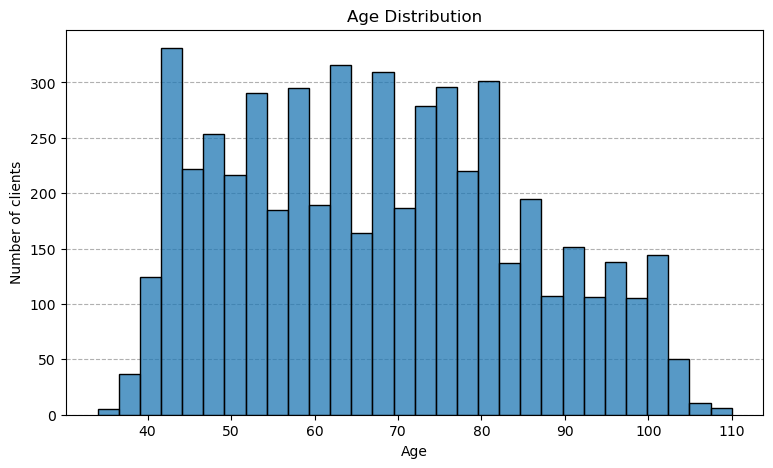

In [66]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=cust_df,
    x="age",
    bins=30 , zorder=3
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of clients")
plt.grid(axis="y", linestyle="--")

plt.show()

In [ ]:
plt.figure(figsize=(9,5))

sns.countplot(data=cust_df,
             x="")

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of clients")
plt.grid(axis="y", linestyle="--")

plt.show()

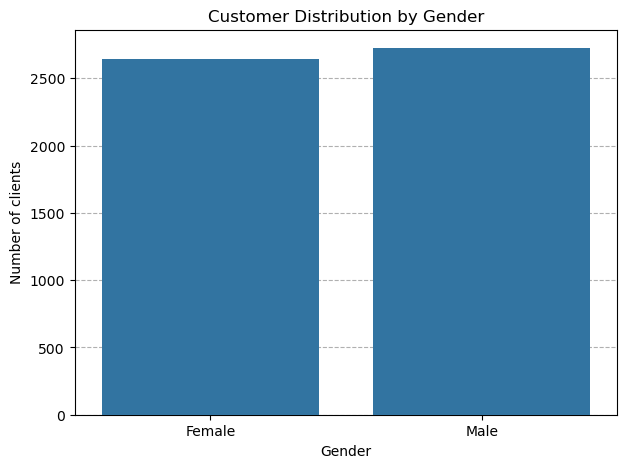

In [67]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=cust_df,
    x="gender",
    zorder=3
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of clients")
plt.grid(axis="y", linestyle="--")

plt.show()

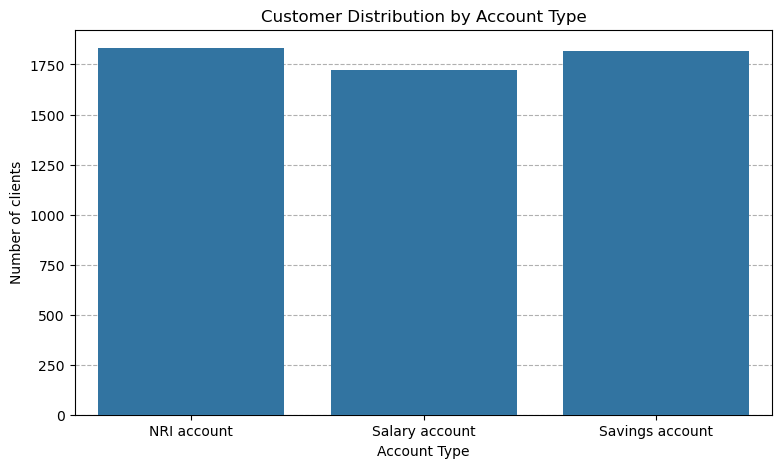

In [70]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=cust_df,
    x="account_type",
    zorder=3
)

plt.title("Customer Distribution by Account Type")
plt.xlabel("Account Type")
plt.ylabel("Number of clients")
plt.grid(axis="y", linestyle="--")

plt.show()

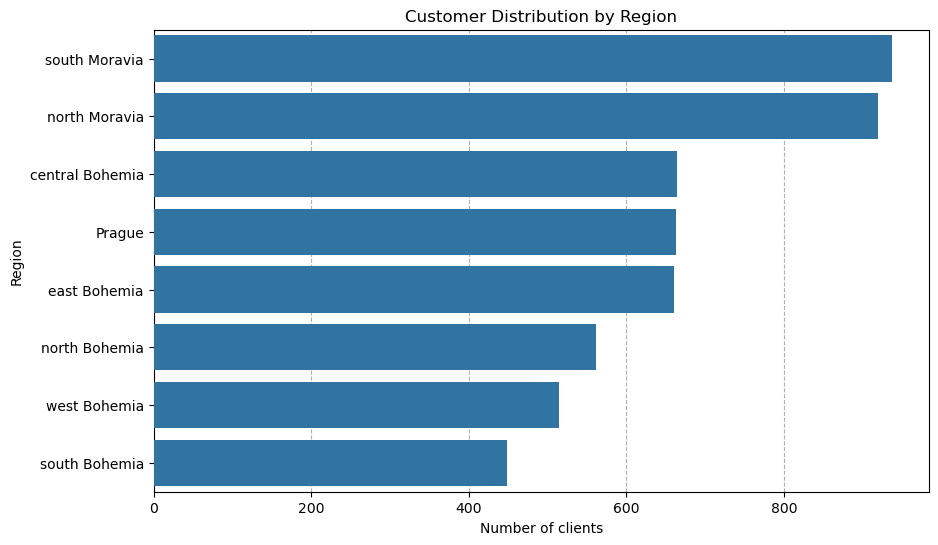

In [71]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=cust_df,
    y="client_region",
    order=cust_df["client_region"].value_counts().index,
    zorder=3
)

plt.title("Customer Distribution by Region")
plt.xlabel("Number of clients")
plt.ylabel("Region")
plt.grid(axis="x", linestyle="--")

plt.show()

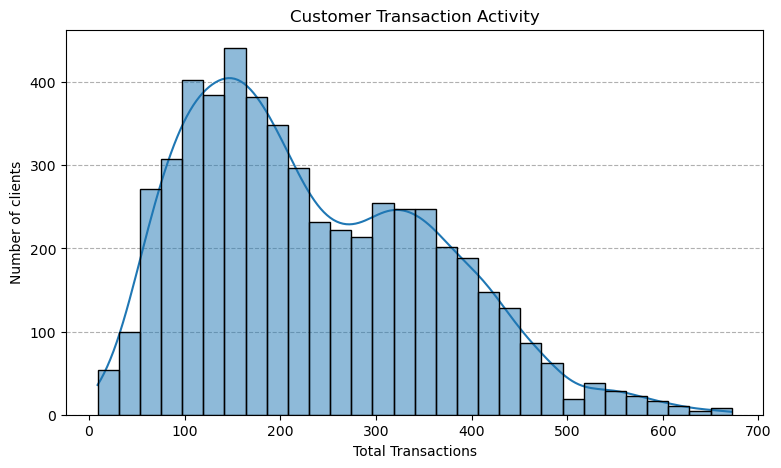

In [74]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=cust_df,
    x="total_transaction",
    bins=30, kde = True,
    zorder=3
)

plt.title("Customer Transaction Activity")
plt.xlabel("Total Transactions")
plt.ylabel("Number of clients")
plt.grid(axis="y", linestyle="--")

plt.show()

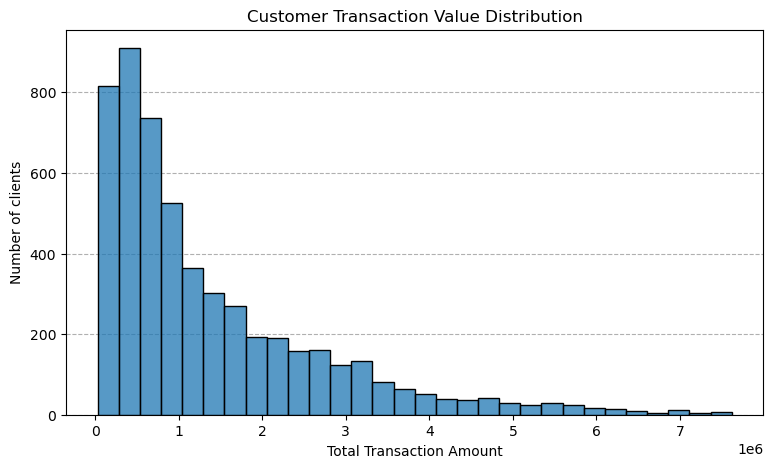

In [75]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=cust_df,
    x="total_transaction_amount",
    bins=30,
    zorder=3
)

plt.title("Customer Transaction Value Distribution")
plt.xlabel("Total Transaction Amount")
plt.ylabel("Number of clients")
plt.grid(axis="y", linestyle="--")

plt.show()

In [78]:
product_summary = pd.DataFrame({
    "Product": ["Account", "Card", "Loan"],
    "Customers": [
        cust_df["total_account"].sum(),
        cust_df["total_card"].sum(),
        cust_df["total_loan"].sum()
    ]
})

product_summary

,Product,Customers
0,Account,5369
1,Card,1043
2,Loan,827


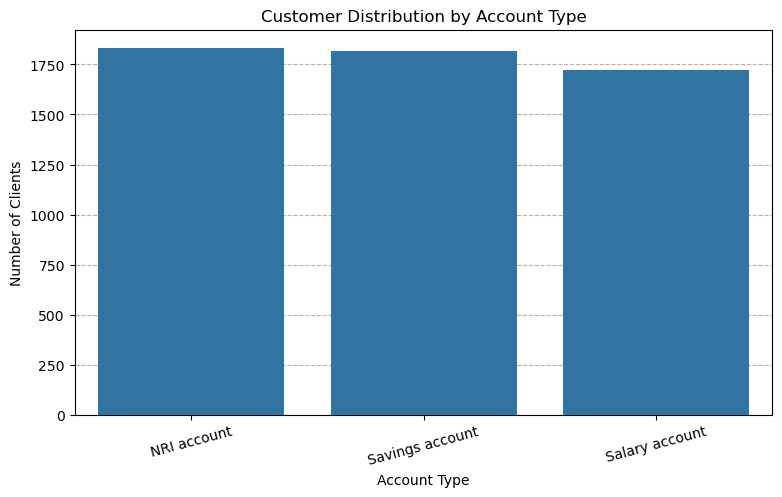

In [79]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=cust_df,
    x="account_type",
    order=cust_df["account_type"].value_counts().index,
    zorder=3
)

plt.title("Customer Distribution by Account Type")
plt.xlabel("Account Type")
plt.ylabel("Number of Clients")
plt.xticks(rotation=15)
plt.grid(axis="y", linestyle="--")

plt.show()

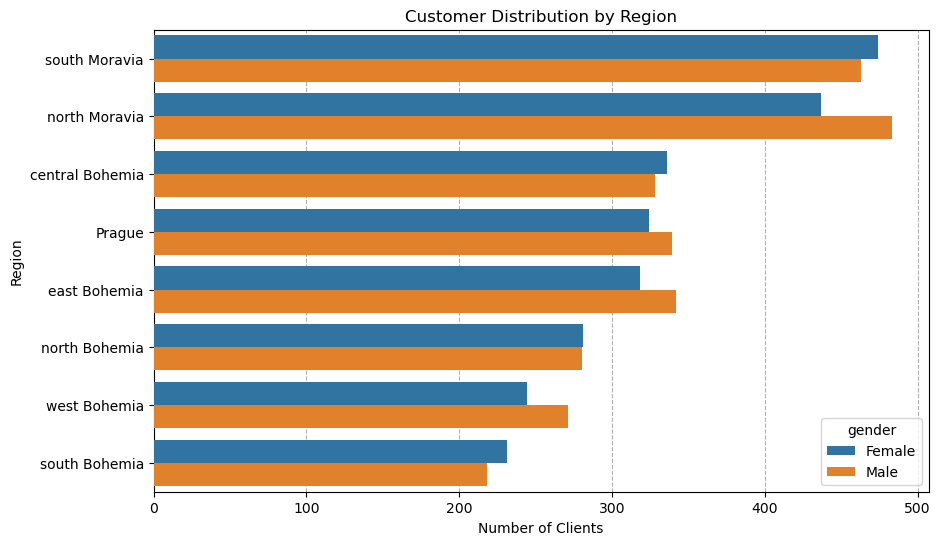

In [82]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=cust_df,
    y="client_region",
    order=cust_df["client_region"].value_counts().index,
    hue="gender",
    zorder=3
)

plt.title("Customer Distribution by Region")
plt.xlabel("Number of Clients")
plt.ylabel("Region")
plt.grid(axis="x", linestyle="--")

plt.show()

In [83]:
pareto_df = (
    cust_df[["client_id", "total_transaction_amount"]]
    .sort_values("total_transaction_amount", ascending=False)
    .reset_index(drop=True)
)

In [84]:
pareto_df["cumulative_value"] = pareto_df["total_transaction_amount"].cumsum()

total_value = pareto_df["total_transaction_amount"].sum()

pareto_df["cumulative_pct"] = (
    pareto_df["cumulative_value"] / total_value * 100
)

In [86]:
top_20_count = int(len(pareto_df) * 0.20)

top_20_value_share = (
    pareto_df.loc[:top_20_count - 1, "total_transaction_amount"].sum()
    / total_value
    * 100
)

top_20_value_share

np.float64(52.2433150808328)

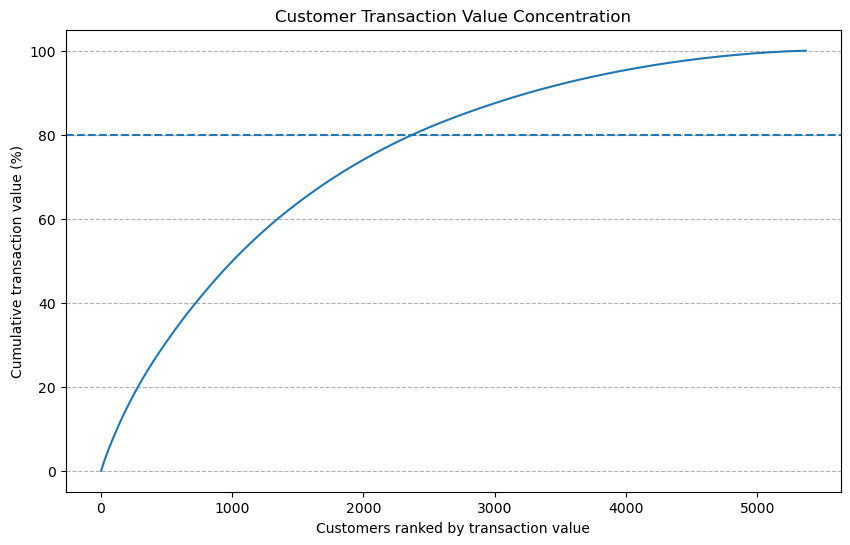

In [87]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(
    pareto_df.index + 1,
    pareto_df["cumulative_pct"]
)

ax1.axhline(80, linestyle="--")

ax1.set_xlabel("Customers ranked by transaction value")
ax1.set_ylabel("Cumulative transaction value (%)")
ax1.set_title("Customer Transaction Value Concentration")
ax1.grid(axis="y", linestyle="--")

plt.show()

In [90]:
product_summary = pd.DataFrame({
    "Product": ["Card", "Loan"],
    "Customers": [
        cust_df["total_card"].sum(),
        cust_df["total_loan"].sum()
    ]
})

product_summary

,Product,Customers
0,Card,1043
1,Loan,827


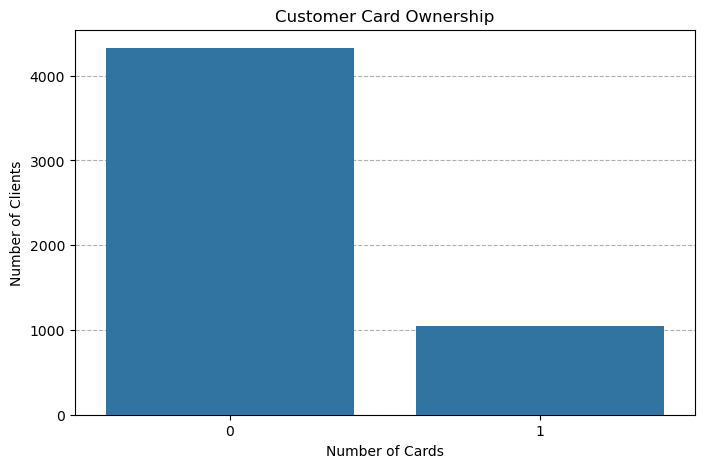

In [92]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=cust_df,
    x="total_card",
    zorder=3
)

plt.title("Customer Card Ownership")
plt.xlabel("Number of Cards")
plt.ylabel("Number of Clients")
plt.grid(axis="y", linestyle="--")

plt.show()

In [93]:
cust_df[
    ["total_transaction", "total_transaction_amount"]
].corr()

,total_transaction,total_transaction_amount
total_transaction,1.000000,0.614316
total_transaction_amount,0.614316,1.000000


In [95]:
cust_df["net_transaction_flow"] = (
    cust_df["total_credit_amount"]
    - cust_df["total_Withdrawal_amount"]
)

In [96]:
cust_df["net_transaction_flow"].describe()

count      5369.000000
mean      44721.287204
std       25531.844883
min      -25584.000000
25%       23806.000000
50%       39215.000000
75%       61456.000000
max      155582.000000
Name: net_transaction_flow, dtype: float64